In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image = cv.imread('images/jumbo.jpg')

## SIFT

In [3]:
feat_sift = cv.xfeatures2d.SIFT_create()
sift_keypoints, descriptors2 = feat_sift.detectAndCompute(image, None)
image_sift = cv.drawKeypoints(image, sift_keypoints, None)

## SURF

In [4]:
feat_surf = cv.xfeatures2d.SURF_create()
surf_keypoints, descriptors2 = feat_surf.detectAndCompute(image, None)
image_surf = cv.drawKeypoints(image, surf_keypoints, None)

error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv_contrib\modules\xfeatures2d\src\surf.cpp:1028: error: (-213:The function/feature is not implemented) This algorithm is patented and is excluded in this configuration; Set OPENCV_ENABLE_NONFREE CMake option and rebuild the library in function 'cv::xfeatures2d::SURF::create'


## ORB

In [5]:
feat_orb = cv.ORB_create(nfeatures=1000)
orb_keypoints, descriptors3 = feat_orb.detectAndCompute(image, None)
image_orb = cv.drawKeypoints(image, orb_keypoints, None)

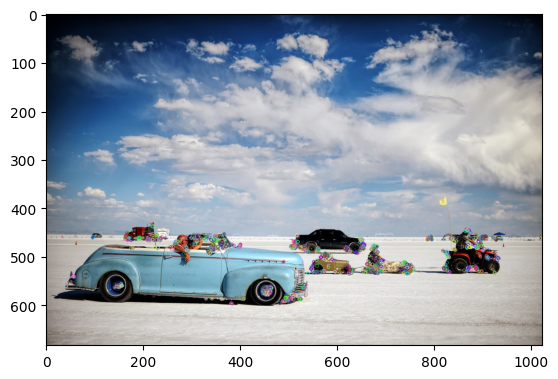

In [6]:
plt.imshow(image_orb[..., ::-1])
plt.show()

In [7]:
image1 = cv.imread('images/book1.png')
image2 = cv.imread('images/book2.png')

## Features matching with ORB

In [8]:
feat_orb = cv.ORB_create(nfeatures=1000)

In [9]:
orb_keypoints1, descriptors1 = feat_orb.detectAndCompute(image1, None)
orb_keypoints2, descriptors2 = feat_orb.detectAndCompute(image2, None)

In [10]:
bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
matches = bf.match(descriptors1, descriptors2)

In [11]:
matches = sorted(matches, key=lambda x: x.distance)

In [14]:
image_matches = cv.drawMatches(image1, orb_keypoints1, image2, orb_keypoints2, matches[:250], None, flags=2)

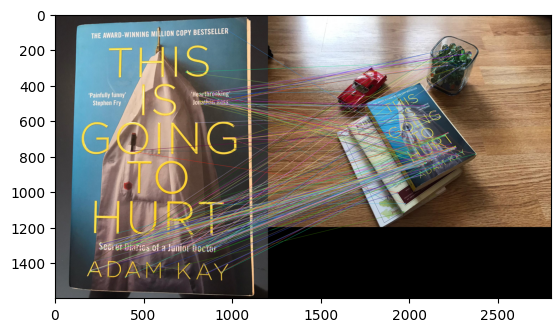

In [15]:
plt.imshow(image_matches[..., ::-1])
plt.show()